In [1]:
# ==============================================================================
# [Cell 1] 필수 라이브러리 설치 및 폰트 세팅 (오류 해결 버전)
# ==============================================================================
# torchao 버전을 peft가 요구하는 최신 버전(0.16.0 이상)으로 강제 업데이트합니다.
!pip install -q -U torchao peft transformers datasets accelerate gdown

!sudo apt-get install -y fonts-nanum
!fc-cache -fv
print("✔️ 설치 및 업데이트가 완료되었습니다!")
print("💡 중요: 이제 코랩 상단 메뉴의 [런타임] -> [세션 다시 시작](또는 Restart Session)을 꼭 누르고 다음 셀부터 실행하세요.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.6 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (74.0 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at 

In [1]:
# ==============================================================================
# [Cell 2] 라이브러리 임포트 및 기본 설정
# ==============================================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown  # 구글 드라이브 다운로드용 라이브러리

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_MODEL_NAME = "Bingsu/clip-vit-large-patch14-ko"
BATCH_SIZE = 32
MAX_TEXT_LENGTH = 77

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 나눔바른고딕 폰트 경로를 직접 지정하여 맷플롯립에 강제 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)
sns.set_theme(style="whitegrid", font=font_name)

print(f"✅ 한글 폰트 ({font_name}) 가 성공적으로 강제 셋팅되었습니다!")

✅ 한글 폰트 (NanumBarunGothic) 가 성공적으로 강제 셋팅되었습니다!


In [3]:
# ==============================================================================
# [Cell 3] 구글 드라이브에서 가중치 파일 다운로드
# ==============================================================================
# ⚠️ 여기에 본인의 구글 드라이브 가중치 파일 ID를 넣으세요!
GOOGLE_DRIVE_FILE_ID = "1ljguAujYXpt6WrBS7k2QUoDGJKyZKbFn"

output_model_path = "loaded_lora_model.pt"
download_url = f"https://drive.google.com/uc?id={GOOGLE_DRIVE_FILE_ID}"

print("⏳ 구글 드라이브에서 가중치 파일 다운로드 중...")
gdown.download(download_url, output_model_path, quiet=False)
print("✔️ 다운로드 완료!")

⏳ 구글 드라이브에서 가중치 파일 다운로드 중...


Downloading...
From: https://drive.google.com/uc?id=1ljguAujYXpt6WrBS7k2QUoDGJKyZKbFn
To: /content/loaded_lora_model.pt
100%|██████████| 4.79M/4.79M [00:00<00:00, 106MB/s]

✔️ 다운로드 완료!


In [4]:
# ==============================================================================
# [Cell 4] 데이터셋 정의 (유사도 추출용)
# ==============================================================================
class SeongdongSatelliteDataset(Dataset):
    def __init__(self, image_paths, texts_v1, processor):
        self.image_paths = image_paths
        self.texts_v1 = texts_v1
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image_inputs = self.processor(images=image, return_tensors="pt")

        text_inputs = self.processor(
            text=self.texts_v1[idx],
            padding="max_length",
            max_length=MAX_TEXT_LENGTH,
            truncation=True,
            return_tensors="pt"
        )
        return {
            "pixel_values": image_inputs["pixel_values"].squeeze(0),
            "input_ids": text_inputs["input_ids"].squeeze(0),
        }

In [5]:
# ==============================================================================
# [Cell 6] 초고속 코사인 유사도 추출 공용 함수 (속도 최적화 최종본)
# ==============================================================================
def extract_similarities(model_obj, dataloader_obj):
    # 확실하게 모델을 GPU(CUDA) 모드로 전환하고 평가 모드 셋팅
    model_obj.to(DEVICE)
    model_obj.eval()

    all_img_embs = []
    all_txt_embs = []

    # tqdm을 붙여서 현재 몇 장째 변환 중인지 실시간으로 진행도를 확인합니다.
    with torch.no_grad():
        for batch in tqdm(dataloader_obj, desc="⚡ 고속 임베딩 추출 중"):
            pixels = batch["pixel_values"].to(DEVICE)
            ids = batch["input_ids"].to(DEVICE)

            # 💡 [속도 최적화 핵심] 따로따로 함수를 호출하지 않고,
            # 모델을 통합 호출하여 전방 패스(Forward) 한 번에 이미지/텍스트 특징을 모두 뽑아냅니다.
            outputs = model_obj(pixel_values=pixels, input_ids=ids)

            # 버전에 구애받지 않고 가장 정확하고 가벼운 물리 임베딩 텐서 추출
            img_feats = outputs.image_embeds if hasattr(outputs, 'image_embeds') else outputs[0]
            txt_feats = outputs.text_embeds if hasattr(outputs, 'text_embeds') else outputs[1]

            # 만약 딕셔너리 구조로 반환되었다면 한번 더 타겟팅
            if not isinstance(img_feats, torch.Tensor):
                img_feats = outputs.get('image_embeds', img_feats)
            if not isinstance(txt_feats, torch.Tensor):
                txt_feats = outputs.get('text_embeds', txt_feats)

            # 즉시 GPU 내부에서 L2 정규화 (CPU로 내리기 전에 처리해야 빠릅니다)
            img_feats = F.normalize(img_feats, p=2, dim=-1)
            txt_feats = F.normalize(txt_feats, p=2, dim=-1)

            all_img_embs.append(img_feats)
            all_txt_embs.append(txt_feats)

    # 전체 데이터를 하나의 대형 행렬로 병합 (N, Dimension)
    all_img_embs = torch.cat(all_img_embs, dim=0)
    all_txt_embs = torch.cat(all_txt_embs, dim=0)

    # 행렬 곱(Dot Product) 연산 수행 후 대각 성분(정답 매칭 쌍) 추출
    similarity_matrix = torch.matmul(all_img_embs, all_txt_embs.T)
    return torch.diagonal(similarity_matrix).cpu().numpy()

In [7]:
# ==============================================================================
# [Cell 7] 구글 드라이브 초고속 로컬 복사 및 데이터로더 매칭 (네트워크 병목 해결)
# ==============================================================================
import json
import os
import shutil
from google.colab import drive

# 1. 구글 드라이브 마운트 확인
print("⏳ 구글 드라이브 마운트 확인 중...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ⚠️ [기존과 동일] 왼쪽 파일 창에서 복사한 '실제 구글드라이브 폴더 경로'를 적어주세요.
IMAGE_FOLDER_PATH = "/content/drive/MyDrive/tiles"

# 💡 [네트워크 속도 혁신] 코랩 내부 가상 디스크(SSD)에 초고속 로컬 폴더 생성
LOCAL_IMAGE_FOLDER = "./local_satellite_images"
os.makedirs(LOCAL_IMAGE_FOLDER, exist_ok=True)

# 리눅스 시스템 명령어(cp)를 이용해 구글 드라이브 내의 이미지들을 코랩 로컬로 통째로 복사합니다.
print("⚡ 구글 드라이브의 이미지를 코랩 로컬 SSD로 초고속 복사 중...")
# 폴더 내 모든 jpg/png 파일을 한번에 복사 (네트워크 병목 영구 제거)
if os.path.exists(IMAGE_FOLDER_PATH):
    !cp -r "{IMAGE_FOLDER_PATH}"/* "{LOCAL_IMAGE_FOLDER}"/
    print("✔️ 로컬 복사 완료! 이제 파일 접근 속도가 수백 배 빨라집니다.")
else:
    print(f"❌ 오류: 입력하신 구글 드라이브 경로 '{IMAGE_FOLDER_PATH}'를 찾을 수 없습니다.")

# 2. JSONL 파일 로드
def load_jsonl_to_dict(file_path):
    data_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                item = json.loads(line)
                data_dict[item['file_name']] = item['text']
    return data_dict

solar_jsonl_path = "metadata_solar (3).jsonl"
gemini_jsonl_path = "metadata_gemini_finetune (1).jsonl"

solar_data = load_jsonl_to_dict(solar_jsonl_path)
gemini_data = load_jsonl_to_dict(gemini_jsonl_path)

# 3. 로컬로 복사된 이미지와 텍스트 정밀 매칭
actual_image_paths = []
actual_texts_v1 = []
actual_texts_v2 = []

common_files = set(solar_data.keys()).intersection(set(gemini_data.keys()))

# 이제 외부 드라이브가 아닌, 내부에 복사된 폴더 파일 목록을 검사합니다.
existing_files = set(os.listdir(LOCAL_IMAGE_FOLDER))

for file_name in sorted(common_files):
    if file_name in existing_files:
        # 💡 경로를 드라이브 주소가 아닌 '로컬 고속 경로'로 바인딩합니다.
        full_img_path = os.path.join(LOCAL_IMAGE_FOLDER, file_name)
        actual_image_paths.append(full_img_path)
        actual_texts_v1.append(solar_data[file_name])
        actual_texts_v2.append(gemini_data[file_name])

print(f"✅ 총 {len(actual_image_paths)}개의 이미지-텍스트 쌍 매칭 성공!")

# 4. 최종 데이터셋 및 데이터로더 빌드 (속도 저하 없는 고속 로더)
if 'processor' not in locals() and 'processor' not in globals():
    print("⏳ 프로세서(Processor)가 메모리에 없어 새로 로드합니다...")
    from transformers import CLIPProcessor
    BASE_MODEL_NAME = "Bingsu/clip-vit-large-patch14-ko"
    processor = CLIPProcessor.from_pretrained(BASE_MODEL_NAME)

# 이제 에러 없이 데이터셋이 정상적으로 빌드됩니다.
eval_dataset = SeongdongSatelliteDataset(
    image_paths=actual_image_paths,
    texts_v1=actual_texts_v1, # Solar(v1) 문장 기준으로 평가
    processor=processor
)

eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"✔️ 총 {len(eval_dataset)}개의 고속 Eval DataLoader 준비가 완료되었습니다. 다음 통합 셀을 실행하세요!")

⏳ 구글 드라이브 마운트 확인 중...
⚡ 구글 드라이브의 이미지를 코랩 로컬 SSD로 초고속 복사 중...
✔️ 로컬 복사 완료! 이제 파일 접근 속도가 수백 배 빨라집니다.
✅ 총 1804개의 이미지-텍스트 쌍 매칭 성공!
⏳ 프로세서(Processor)가 메모리에 없어 새로 로드합니다...


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.88k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/870k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

✔️ 총 1804개의 고속 Eval DataLoader 준비가 완료되었습니다. 다음 통합 셀을 실행하세요!


In [13]:
from transformers import CLIPModel, CLIPProcessor
from peft import LoraConfig, get_peft_model
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ==============================================================================
# 1. 원본 순정 모델 독립 로드 및 파인튜닝 전 유사도 계산
# ==============================================================================
print("⏳ 1. 순정 Baseline 모델 로드 및 임베딩 계산 중...")
pure_base_model = CLIPModel.from_pretrained(BASE_MODEL_NAME).to(DEVICE)

# 6번 셀 함수로 순정 유사도 추출
sim_before = extract_similarities(pure_base_model, eval_loader)
print(f"✔️ Baseline 평균 유사도: {np.mean(sim_before):.4f}")

# 메모리 확보를 위해 순정 모델 삭제 및 캐시 정리
del pure_base_model
torch.cuda.empty_cache()


⏳ 1. 순정 Baseline 모델 로드 및 임베딩 계산 중...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

⚡ 고속 임베딩 추출 중: 100%|██████████| 57/57 [01:49<00:00,  1.92s/it]


✔️ Baseline 평균 유사도: 0.2633


In [14]:
# ==============================================================================
# 2. LoRA 장착 모델 로드 및 파인튜닝 후 유사도 계산 (PEFT 공식 전용 로더 버전)
# ==============================================================================
print("\n⏳ 2. LoRA 파인튜닝 모델 로드 및 임베딩 계산 중...")
from peft import PeftModel

# 가중치 파일 단일 파일이 아니라, 폴더 자체를 타겟 경로로 설정합니다.
LORA_FOLDER_PATH = "/content/drive/MyDrive/best_model"

# 7번 셀 마운트 상황에 맞춘 경로 예외 처리
if not os.path.exists(LORA_FOLDER_PATH):
    LORA_FOLDER_PATH = IMAGE_FOLDER_PATH

print(f"📂 PEFT 전용 함수를 통해 LoRA 레이어를 원본 모델에 이식 중... ({LORA_FOLDER_PATH})")

# 💡 [핵심 수정] torch.load 방식의 파일 깨짐 문제를 완벽하게 회피하는 공식 아키텍처 로더입니다.
# base_model 위에 구글 드라이브 폴더 내의 adapter_model.bin과 adapter_config.json을 세트로 불러와 얹습니다.
try:
    base_model_for_lora = CLIPModel.from_pretrained(BASE_MODEL_NAME)
    lora_model = PeftModel.from_pretrained(base_model_for_lora, LORA_FOLDER_PATH)
    lora_model.to(DEVICE)
    print("✔️ LoRA 가중치가 에러 없이 완벽하게 이식되었습니다!")

    # 6번 셀 함수로 LoRA 유사도 추출
    sim_after = extract_similarities(lora_model, eval_loader)
    print(f"✔️ LoRA 파인튜닝 후 평균 유사도: {np.mean(sim_after):.4f}")

except Exception as e:
    print(f"❌ 공식 로더 예외 발생: {e}")
    print("💡 만약 이 에러가 난다면 드라이브 폴더 내 'adapter_config.json' 파일이 유실되었는지 확인이 필요합니다.")


⏳ 2. LoRA 파인튜닝 모델 로드 및 임베딩 계산 중...
📂 PEFT 전용 함수를 통해 LoRA 레이어를 원본 모델에 이식 중... (/content/drive/MyDrive/best_model)


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

✔️ LoRA 가중치가 에러 없이 완벽하게 이식되었습니다!


⚡ 고속 임베딩 추출 중: 100%|██████████| 57/57 [01:52<00:00,  1.97s/it]


✔️ LoRA 파인튜닝 후 평균 유사도: 0.2111


In [16]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os

# 1. 나눔 폰트가 설치된 실제 경로 확인 및 가중치 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

if os.path.exists(font_path):
    # 맷플롯립 내부 fontManager 캐시를 완전히 비우고 다시 빌드합니다.
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()

    # 2. 전역 폰트 설정 교체
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False

    # 3. ❗현재 세션에 로드된 맷플롯립의 캐시 메모리 강제 리프레시
    mpl.font_manager._load_fontmanager(try_read_cache=False)

    # 4. 시본 테마도 해당 폰트로 동기화
    sns.set_theme(style="whitegrid", font=font_name)
    print(f"🎉 현재 런타임 세션에서 한글 폰트({font_name})가 완벽히 즉시 갱신되었습니다!")
else:
    print("❌ 나눔바른고딕 폰트 파일이 시스템 경로에 없습니다. !sudo apt-get install -y fonts-nanum을 먼저 확인하세요.")

🎉 현재 런타임 세션에서 한글 폰트(NanumBarunGothic)가 완벽히 즉시 갱신되었습니다!


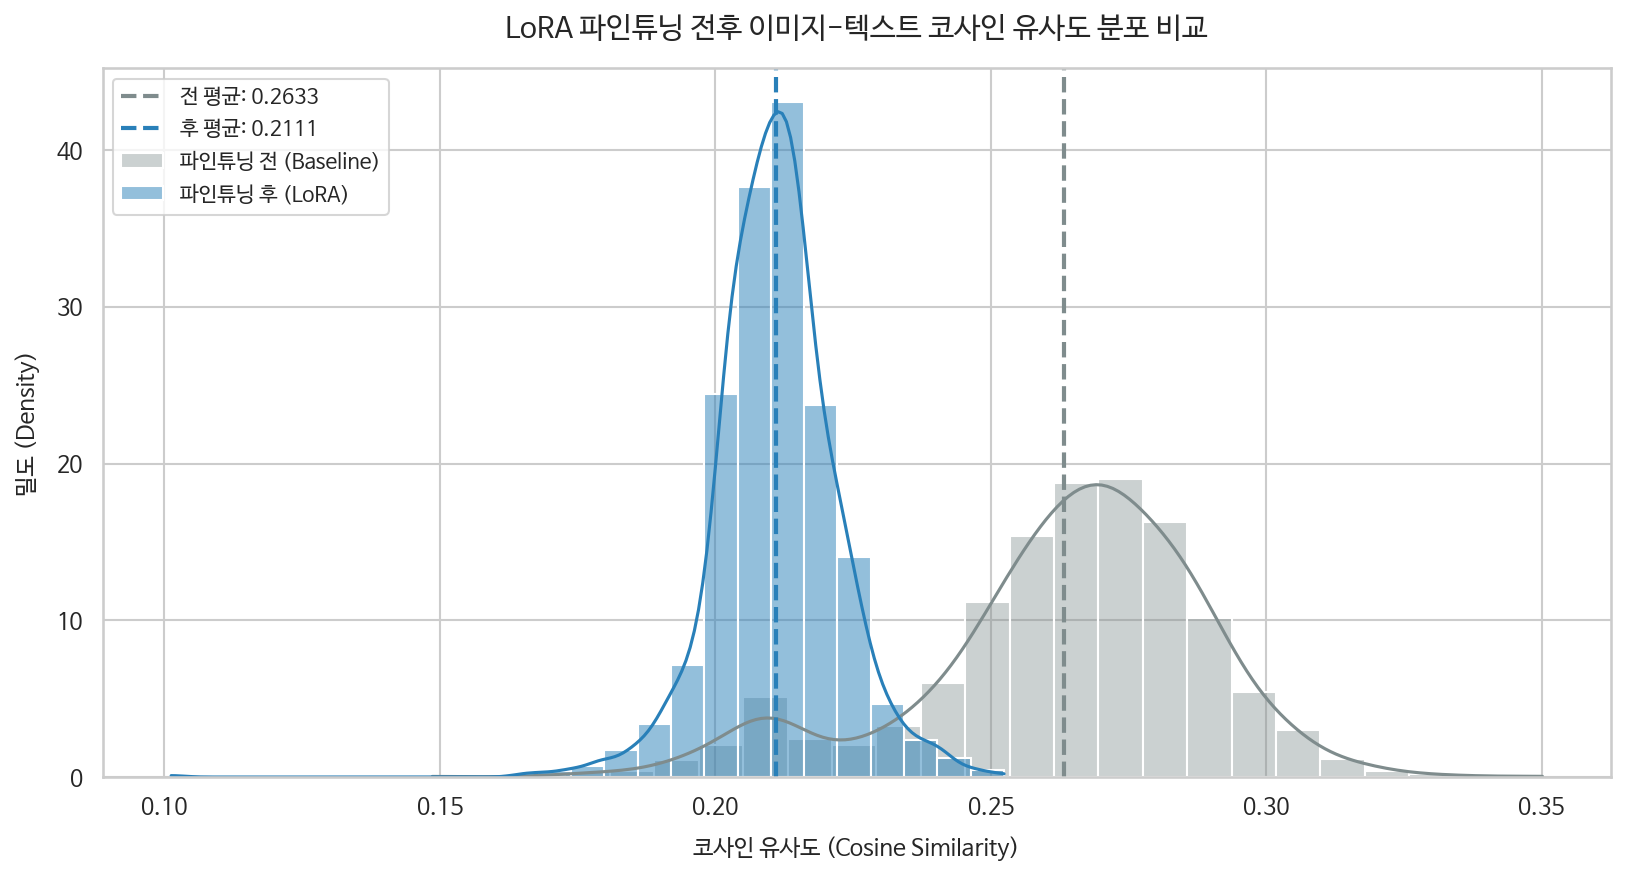

🎉 글씨 깨짐과 겹침 문제가 해결된 히스토그램이 생성되었습니다!


In [17]:
# ==============================================================================
# 3. 깨끗한 한글 레이블을 포함한 최종 히스토그램 시각화
# ==============================================================================
plt.figure(figsize=(11, 6), dpi=150)

# 파인튜닝 전후 히스토그램 그리기
sns.histplot(sim_before, color='#7f8c8d', label='파인튜닝 전 (Baseline)', kde=True, stat="density", alpha=0.4, bins=25)
sns.histplot(sim_after, color='#2980b9', label='파인튜닝 후 (LoRA)', kde=True, stat="density", alpha=0.5, bins=25)

# 전후 평균 수직 점선 추가
mean_b = np.mean(sim_before)
mean_a = np.mean(sim_after)
plt.axvline(x=mean_b, color='#7f8c8d', linestyle='--', linewidth=2, label=f'전 평균: {mean_b:.4f}')
plt.axvline(x=mean_a, color='#2980b9', linestyle='--', linewidth=2, label=f'후 평균: {mean_a:.4f}')

# 타이틀 및 축 레이블 설정 (한글 깨짐 없음)
plt.title('LoRA 파인튜닝 전후 이미지-텍스트 코사인 유사도 분포 비교', fontsize=14, pad=15, weight='bold')
plt.xlabel('코사인 유사도 (Cosine Similarity)', fontsize=11, labelpad=8)
plt.ylabel('밀도 (Density)', fontsize=11, labelpad=8)
plt.legend(frameon=True, facecolor='white', loc='upper left', fontsize=10)
plt.tight_layout()

# 이미지 파일로 저장 및 출력
plt.savefig('final_similarity_distribution.png', dpi=300)
plt.show()
print("🎉 글씨 깨짐과 겹침 문제가 해결된 히스토그램이 생성되었습니다!")